In [31]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd


sys.path.append('..')
import plot_settings
plot_settings.apply()
colors = plot_settings.colors()

# Importing data

In [94]:

def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        delim_whitespace=True,
        comment="%",
        header=None
    )

    df.columns = ['u_par','C','t','E_cell (V)','I_cell (A)','Rx_cell (N)','u_cell (m)','E_ocv_cell (V)']

    # Sort by time within each batch
    df = df.sort_values(["C", "t"])
    return df




path = f'test_data_20p'

data = read_data(path)

#rename columns
data.columns = ['u_par','C','t','V_t','I','Rx','u','ocv']

print(data['C'].unique())
print(data['u_par'].unique())


[0.7 0.8 1.1 1.3 1.4 1.8 2.  2.3 2.6 2.8 3.2 3.3 3.6 3.7 3.9 4.2 4.3 4.7
 4.9]
[ -3.5 -25.6  24.   10.2 -10.   21.6   0.9  18.4  -7.7  -0.9 -28.9   5.5
 -20.6 -16.6   8.4  12.9  17.   29.4 -23.4 -14.3]


/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_23797/2597852786.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


# Plotting data

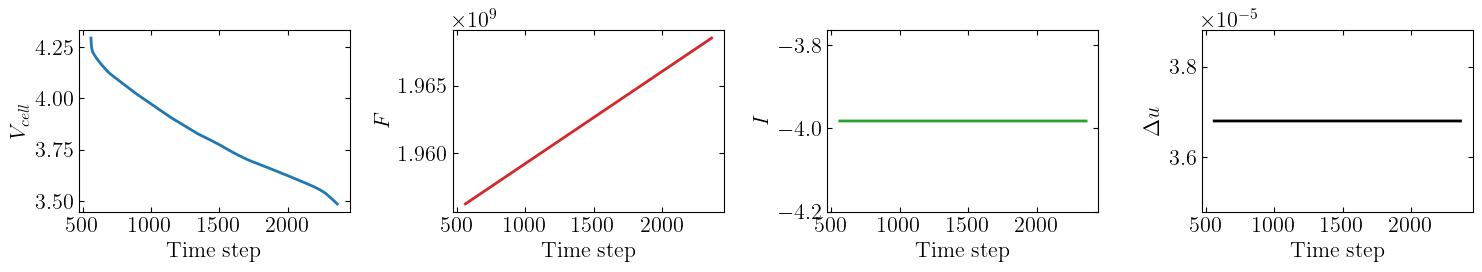

In [95]:
C_rate = 0.8
plot_idx = data['C'] == C_rate
f, ax = plt.subplots(1, 4, figsize=(15, 3))
ax[0].plot(data['V_t'][plot_idx], '-', color = colors[0], lw = 2)
ax[0].set_xlabel('Time step')
ax[0].set_ylabel('$V_{cell}$')
ax[1].plot(data['Rx'][plot_idx], lw = 2,color = colors[1])
ax[1].set_xlabel('Time step')
ax[1].set_ylabel('$F$')
ax[2].plot(data['I'][plot_idx], lw = 2,color = colors[2])
ax[2].set_xlabel('Time step')
ax[2].set_ylabel('$I$')
ax[3].plot(data['u'][plot_idx], lw = 2,color = colors[3])
ax[3].set_xlabel('Time step')
ax[3].set_ylabel(r'$\Delta u$')

plt.tight_layout()
plt.show()

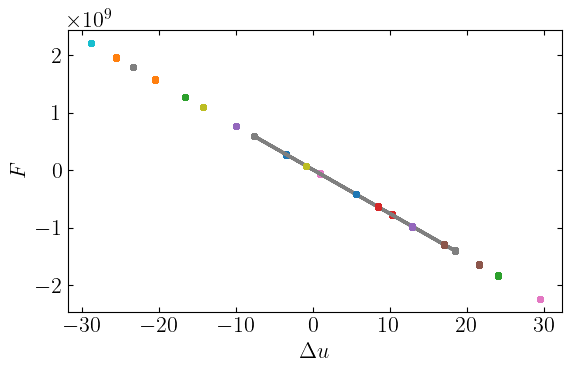

In [98]:
# plot u vs F

f, ax = plt.subplots(figsize=(6, 4))
for C_rate in data['C'].unique():
    plot_idx = data['C'] == C_rate
    ax.plot(data['u_par'][plot_idx], data['Rx'][plot_idx], lw = 2, label=f'C={C_rate}', marker='o', markersize=4)
ax.set_xlabel(r'$\Delta u$')
ax.set_ylabel('$F$')
#plt.legend()
plt.tight_layout()
plt.show()

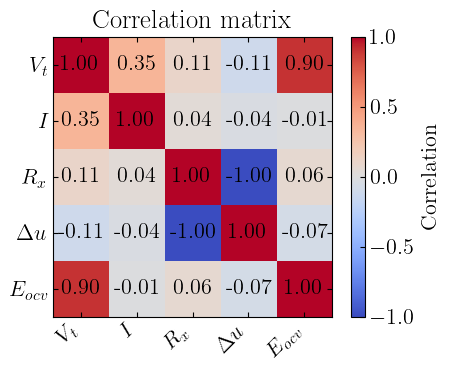

In [99]:
# Correlation matrix for current signals in this batch

X = data[['V_t','I','Rx','u_par','ocv']].values
feature_names = ['$V_t$','$I$','$R_x$',r'$\Delta u$','$E_{ocv}$']
with np.errstate(invalid="ignore", divide="ignore"):
    corr = np.corrcoef(X, rowvar=False)


fig, ax_corr = plt.subplots(figsize=(5, 4))
im = ax_corr.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax_corr.set_xticks(np.arange(len(feature_names)))
ax_corr.set_yticks(np.arange(len(feature_names)))
ax_corr.set_xticklabels(feature_names, rotation=45, ha="right")
ax_corr.set_yticklabels(feature_names)
ax_corr.set_title("Correlation matrix")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax_corr.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax_corr, label="Correlation")
plt.tight_layout()
plt.show()

In [ ]:
def plot_histograms(D, vars_to_plot, transform_func=transform, bins=50, alpha=0.5, plot_colors=None):
    n_vars = len(vars_to_plot)
    n_cols = min(3, n_vars)
    n_rows =  2 * math.ceil(n_vars / n_cols)

    if plot_colors is None:
        plot_colors = ['tab:blue', 'tab:red', 'tab:green', 'black', 'tab:orange', 'tab:purple']

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*math.ceil(n_vars/3)))
    axes = np.array(axes).reshape(n_rows, n_cols)

    for idx, var in enumerate(vars_to_plot):
        col_idx = idx % n_cols
        row_block = (idx // n_cols) * 2

        # normalized
        ax = axes[row_block, col_idx]
        arr_n = transform_func(D[var], var)
        mask_n = get_valid_mask(arr_n, D['valid'])
        vals_n = arr_n[mask_n]
        ax.hist(vals_n, bins=bins, alpha=alpha, color=plot_colors[idx % len(plot_colors)],
               edgecolor='black', label=f'{var}_n',density = True)
        ax.legend()

        # original
        ax = axes[row_block + 1, col_idx]
        arr = D[var]
        mask = get_valid_mask(arr, D['valid'])
        vals = arr[mask]
        ax.hist(vals, bins=bins, alpha=alpha, color=plot_colors[idx % len(plot_colors)],
                edgecolor='black', label=f'{var}', density = True)
        ax.legend()

# Normalizing data

### Characteristics that should be preserved after normalization?


- $\Delta u$: It should primarily be compression, so have a negative sign. 
    - $\Delta u / L$ gives a fractional compression 
- $I$: The sign of it should reflect if we have charge/discharge
    - Maybe just a `standard` normalization on this? 
- $V$: It should always be positive
    - Maybe just a `min-max` normalization on this? 
- $F$: The sign of it should in some way reflect the sign of $\Delta u$. Especially in the cases with low swelling. 
    - Maybe just a `standard` normalization on this? 

# Splitting data

In [ ]:

# Flatten time dimension for training
B, T, C = x.shape
_,_, Tar = y.shape

# Split
split = int(0.8 * B)
def _split(arr):
    return arr[:split], arr[split:]

def _split_flat(arr):
    return arr[:split].flatten(0,1), arr[split:].flatten(0,1)   # Same as reshape(B * T, C)    # (B*T, 4)


x_train, x_test = _split_flat(x)
y_train, y_test = _split_flat(y)
mask_train, mask_test = _split_flat(mask)

cnr_train, cnr_test = _split(cnr)
cpr_train, cpr_test = _split(cpr)
cnr_dot_train, cnr_dot_test = _split(cnr_dot)
cpr_dot_train, cpr_dot_test = _split(cpr_dot)
I_train, I_test = _split(I)

# x_train_batch, x_test_batch = x[:split], x[split:]
# y_train_batch, y_test_batch = y[:split], y[split:]
# mask_train_batch, mask_test_batch = mask[:split], mask[split:]


# Un-normalized for plotting
# cn_test = cn[split:]
# cp_test = cp[split:]
# cn_dot_test = cn_dot[split:]
# cp_dot_test = cp_dot[split:]
# I_test = I[split:]
# dI_test = dI[split:]
# mask_test_plot = valid[split:]

# V_test = V[split:]

# cn_train = cn[:split]
# cp_train = cp[:split]
# cn_dot_train = cn_dot[:split]
# cp_dot_train = cp_dot[:split]
# I_train = I[:split]
# dI_train = dI[:split]
# mask_train_plot = valid[:split]

print('Shapes:', x_train.shape, y_train.shape, mask_train.shape)


#batch_size_small = int(B/4)
batch_size_large = int(B*T/4)
#train_loader_batch = DataLoader(TensorDataset(x_train_batch, y_train_batch, mask_train_batch), batch_size=batch_size_small, shuffle=True)
train_loader_flat = DataLoader(TensorDataset(x_train, y_train, mask_train), batch_size=batch_size_large, shuffle=True)

# Defining model

Inputs: $I_t$, $\Delta u_t$

Outputs $\dot{V}_t$, $\dot{F}_t$

Employing a NODE setup, with the state variable $\xi = [V,F]$, we get $$\dot{\xi}=f_{NN}(I_t,\Delta u_t)\Rightarrow \xi(t) = \int_0^tf_{NN}(I_t,\Delta u_t)\,\mathrm{d}t$$

In [ ]:
''' Mk 1 '''
class Net(nn.Module):
    def __init__(self, input_size=2, hidden_size=256): 
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)   # output size is 2 for (V_cell, F)
        )
    
    # def forward(self, x):
    #     x = self.net(x)
    #     return x
    def forward(self, input, PE = False):
        if PE:
            pass
        else:
            return self.net(input)
    
model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training
Since we only have values for $V_t$ and $F_t$, we need to add a torch-compatible integrator within the training procedure. For starters, we use the simple Euler forward, yielding the following loss $$\mathcal{L} = \|\xi_t-f_{NN}(x_t)\Delta t\|^2_2\quad x_t = [I_t,\Delta u_t].$$
After training, the model could in principle be used in your favorite integrator. 

In [ ]:
def training(epochs=30, PE = True):
    history = {"loss": [], "d_loss": [], "p_loss": [], "time per ep": []}
    for ep in range(epochs):
        model.train()
        tot_ep_loss = 0.0
        d_ep_loss = 0.0
        p_ep_loss = 0.0
        start_t = time.perf_counter()

        for x_b, y_b, mask_b in train_loader_flat:
            # print('batch shapes:', x_b.shape, y_b.shape, mask_b.shape)
            pred = model(x_b)   # [B*T, 2]
            d_loss = masked_mse(pred, y_b, mask_b)
            p_loss = 0
            tot_loss = d_loss + p_loss
            # print('pred shapes:', pred.shape)
            optimizer.zero_grad()
            tot_loss.backward()
            optimizer.step()
            tot_ep_loss += d_loss.item() + p_loss
            d_ep_loss += d_loss.item()
            p_ep_loss += p_loss

        tot_last = tot_ep_loss / len(train_loader_flat)  # Average loss per batch
        d_last = d_ep_loss / len(train_loader_flat)
        p_last = p_ep_loss / len(train_loader_flat)
        end_t = time.perf_counter()

        history["loss"].append(tot_last)
        history["d_loss"].append(d_last)
        history["p_loss"].append(p_last)
        history["time per ep"].append(end_t - start_t)
        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')
        print(f"Epoch {ep+1} | loss {tot_last:.3e} | d_loss {d_last:.3e} | time {end_t - start_t:.2f}s")

    return history

In [ ]:
model_name = 'Second_PENN_ReLU'
PENN_exp_log.exp_log(model, history, current = currents,name=model_name, d_loss_type = 'mse')
torch.save(model.state_dict(), f'models/{model_name}_{currents}.pth')
print(history['loss'][-1])
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))
ax1.semilogy(history["loss"], label="Train loss")
# ax1.set_yscale("log")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend()